In [16]:
import pandas as pd

df = pd.read_csv("../data/vnexpress_clean_data.csv", usecols=["title", "content" ,"group"])
print(df.head())


      group                                            content  \
0  Sức khỏe  Từ đầu tháng 3 đến nay miền Nam liên tiếp xảy ...   
1  Sức khỏe  TS BS Trần Vũ Minh Thư Trưởng khoa Nội tim mạc...   
2  Giải trí  Dịp Tết Bính Ngọ hai hoa hậu dành thời gian du...   
3  Giải trí  Tăng Thanh Hà và chồng doanh nhân Louis Nguyễn...   
4  Giải trí  Tác phẩm do Brett Ratner đạo diễn ra rạp Mỹ hô...   

                                               title  
0                   Vì sao ăn bánh mì có thể ngộ độc  
1    Khám đau cột sống bất ngờ phát hiện hẹp van tim  
2    Thời trang đồng điệu của Kỳ Duyên Đoàn Thiên Ân  
3     Dàn sao dạo đường hoa Nguyễn Huệ ngày khai mạc  
4  Phim về bà Melania Trump hút khán giả dù bị ch...  


In [17]:
import re
from underthesea import word_tokenize

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    # remove url, email
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)

    # remove special characters
    text = re.sub(r"[^a-zA-ZÀ-ỹ\s]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    text = word_tokenize(text, format="text")

    return text


In [18]:
df["text"] = ((df["title"] + " ") * 3 + df["content"]).apply(clean_text)

In [19]:
from collections import Counter

all_words = " ".join(df["text"]).split()

word_freq = Counter(all_words)

In [20]:
import pandas as pd

freq_df = pd.DataFrame(word_freq.items(), columns=["word", "count"])
freq_df = freq_df.sort_values(by="count", ascending=False)

freq_df


,word,count
57,và,8439
387,của,6454
34,trong,5929
21,là,5201
92,các,5086
...,...,...
35027,khóe_miệng,1
35026,tộcnăm,1
35025,cự_nhân,1
35024,hán_giới,1


In [21]:
stopwords = {
"và","của","trong","là","các","có","khi","cho","với","được",
"một","nhiều","để","ở","những","đến","sau","từ","tôi","anh",
"cô","ông","bà","em","mình","họ","ta","như","về","này",
"hoặc","vào","đó","ra","trên","theo","cũng","còn","do",
"nhưng","vì","mỗi","nếu","mà","hay","cả","đây","ai","dù",
"ít","luôn","tới","nay","đều","nên","đã","sẽ","đang"
}


In [22]:
def remove_stopwords(text):
    tokens = text.split()
    tokens = [w for w in tokens if w not in stopwords]
    return " ".join(tokens)

df["text_clean"] = df["text"].apply(remove_stopwords)
print(df["text_clean"].head())



0    sao ăn bánh_mì có_thể ngộ_độc sao ăn bánh_mì c...
1    khám đau cột_sống bất_ngờ phát_hiện hẹp van ti...
2    thời_trang đồng_điệu kỳ_duyên_đoàn thiên_ân th...
3    dàn sao dạo đường hoa nguyễn_huệ ngày khai_mạc...
4    phim melania trump hút khán_giả bị chê nội_dun...
Name: text_clean, dtype: object


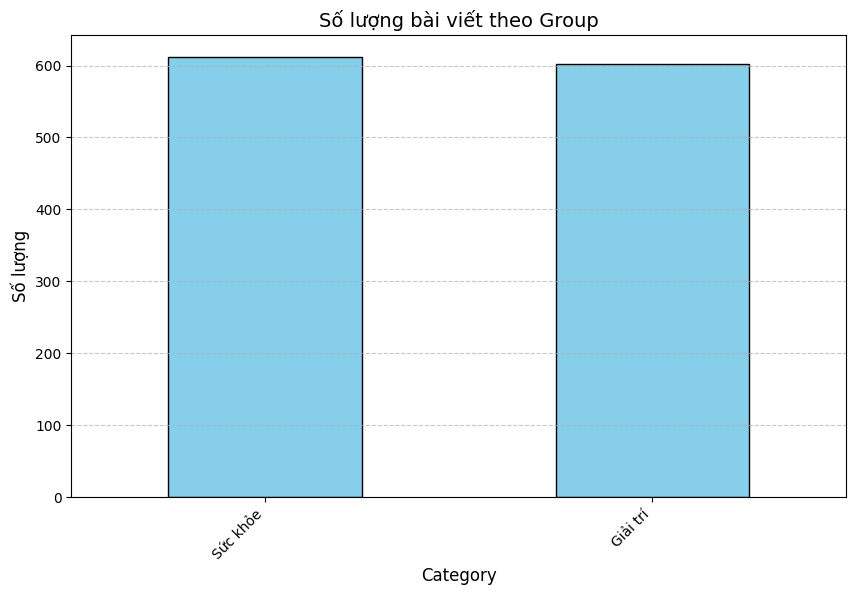

In [26]:
import matplotlib.pyplot as plt

group_counts = df['group'].value_counts()

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 6))
group_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Số lượng bài viết theo Group', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Khởi tạo TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,     # số lượng từ đặc trưng tối đa
    ngram_range=(1,2),     # xét cả 1-gram và 2-gram
    min_df=3,              # bỏ từ xuất hiện ít hơn 3 văn bản
    max_df=0.8             # bỏ từ xuất hiện quá phổ biến (>80% văn bản)
)

# Chuyển văn bản thành ma trận TF-IDF
X = vectorizer.fit_transform(df["text_clean"])

# Nhãn (chuyên mục)
y = df["group"]

print("Kích thước ma trận TF-IDF:", X.shape)


Kích thước ma trận TF-IDF: (1214, 5000)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression cho binary classification
model = LogisticRegression(max_iter=1000, C=4)

# Huấn luyện
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",4
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Dự đoán trên tập test
y_pred = model.predict(X_test)

# Lấy xác suất dự đoán
proba = model.predict_proba(X_test)

# Độ chính xác
print("Accuracy:", accuracy_score(y_test, y_pred))

# Báo cáo chi tiết
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9835390946502057

 Classification Report:
               precision    recall  f1-score   support

    Giải trí       0.98      0.99      0.98       120
    Sức khỏe       0.99      0.98      0.98       123

    accuracy                           0.98       243
   macro avg       0.98      0.98      0.98       243
weighted avg       0.98      0.98      0.98       243



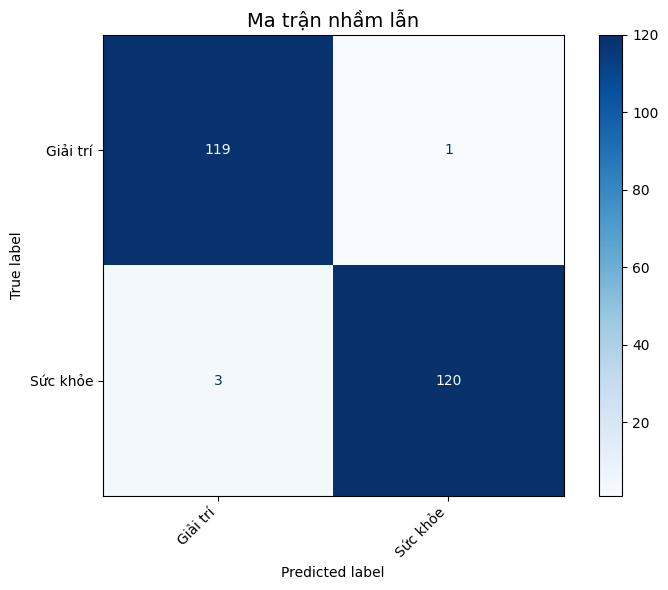

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
labels = sorted(list(set(y_test)))

# Hiển thị ma trận nhầm lẫn
fig, ax = plt.subplots(figsize=(8, 6)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, colorbar=True)

# Tùy chỉnh hiển thị
plt.title("Ma trận nhầm lẫn", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [43]:
# Tạo dataframe kết quả
result_df = pd.DataFrame({
    "title": df.loc[y_test.index, "title"],
    "content": df.loc[y_test.index, "content"],
    "clean_text": df.loc[y_test.index, "text_clean"],
    "true_label": y_test,
    "pred_label": y_pred,
    "confidence": proba.max(axis=1)
})

# Lọc các bài sai
wrong_df = result_df[result_df["true_label"] != result_df["pred_label"]]

print("Số bài sai:", len(wrong_df))
print("="*100)

row = wrong_df.iloc[2]

print("TITLE:", row["title"])
print("\nCONTENT:", row["content"][:400])
print("\nCLEAN TEXT:", row["clean_text"][:400])
print("\nTRUE:", row["true_label"])
print("PRED:", row["pred_label"])
print("CONFIDENCE:", row["confidence"])

    

Số bài sai: 4
TITLE: H Hen Niê đồng hành giải chạy vì trẻ em sống chung với bệnh hiếm

CONTENT: Trong lễ phát động giải chạy tại Hà Nội sáng 1 3 H Hen Niê cho biết từng hỗ trợ một trẻ bị ung thư máu Cô bế bệnh nhi này lên sàn diễn để bé cảm nhận cuộc sống sự yêu thương của mọi người có được sức mạnh chiến đấu bệnh tật Khi làm mẹ cô càng thấu hiểu nỗi đau của những người không may mắn có con bị bệnh Tôi muốn lan tỏa dự án này một cách mạnh mẽ để các gia đình thấy được sự quan tâm chia sẻ của 

CLEAN TEXT: h hen niê đồng_hành_giải chạy trẻ_em sống chung bệnh hiếm_h hen niê đồng_hành_giải chạy trẻ_em sống chung bệnh hiếm_h hen niê đồng_hành_giải chạy trẻ_em sống chung bệnh hiếm lễ phát_động giải chạy tại hà_nội sáng h hen_niê biết từng hỗ_trợ trẻ bị ung_thư máu bế bệnh_nhi lên sàn_diễn bé cảm_nhận cuộc_sống sự yêu_thương mọi người sức_mạnh chiến_đấu bệnh_tật làm mẹ càng thấu_hiểu nỗi đau người không 

TRUE: Giải trí
PRED: Sức khỏe
CONFIDENCE: 0.7391989847927332


In [44]:
def predict_category(title, content):
    text = clean_text(title + " " + content)
    text = remove_stopwords(text)
    vector = vectorizer.transform([text])
    category = model.predict(vector)[0]

    return category

# Thử ví dụ
print(predict_category(
    "Uống nước ấm buổi sáng có lợi gì cho sức khỏe?", 
    """
        Nhiều người cho rằng uống nước ấm buổi sáng giúp giải độc, cải thiện tiêu hóa, tăng cường trao đổi chất hoặc giảm cân. Vậy điều này có đúng?
        Nếu uống nước ấm là một phần trong thói quen hằng ngày, bạn hoàn toàn có thể tiếp tục. Tuy nhiên, với những người uống nước ấm vì kỳ vọng lợi ích sức khỏe cụ thể, kết quả có thể không như mong đợi, theo HuffPost (Mỹ).
        Chỉ hỗ trợ hệ tiêu hóa ở mức độ nhất định
        Bác sĩ tiêu hóa Isaiah Schuster, làm việc tại St. Francis Hospital & Heart Center (Mỹ), cho biết đồ uống nóng hoặc ấm có thể giúp hệ tiêu hóa hoạt động thuận lợi hơn. Nhiệt độ ấm giúp các cơ vòng trong đường tiêu hóa thư giãn, từ đó hỗ trợ thức ăn di chuyển dễ dàng.
        Ví dụ, uống cà phê hoặc nước ấm vào buổi sáng có thể kích thích quá trình này, giúp thực quản và đường tiêu hóa vận hành trơn tru hơn.
        Đồ uống ấm còn có thể kích thích phản xạ dạ dày-đại tràng, tức cơ chế khiến ruột già hoạt động mạnh hơn, từ đó hỗ trợ thúc đẩy nhu động ruột và cải thiện tình trạng táo bón.
        Tuy nhiên, theo bác sĩ phẫu thuật giảm cân Vanessa Buie, UChicago Medicine (Mỹ), cơ thể con người hoạt động tốt nhất ở nhiệt độ khoảng 37 độ C, vì vậy uống nước quá lạnh hoặc quá nóng có thể tạm thời ảnh hưởng tiêu cực đến nhu động dạ dày và tiêu hóa.
        Ngoài ra, quá trình tiêu hóa chủ yếu được điều chỉnh bởi hormone, nên những yếu tố như mức độ căng thẳng hoặc chất lượng giấc ngủ thường ảnh hưởng đến tiêu hóa nhiều hơn là một cốc nước ấm.
    """
))


Sức khỏe


# Kết luận

Bài toán dự đoán chuyên mục bài báo từ nội dung văn bản là **bài toán phân lớp văn bản (text classification)**.  
Dữ liệu có nhãn rõ ràng và chứa nhiều thông tin ngữ nghĩa, do đó **có thể sử dụng các phương pháp học máy để xây dựng mô hình dự đoán**.
